# Zadanie 1

In [42]:
import numpy as np
from scipy.linalg import hilbert
import timeit
import matplotlib.pyplot as plt

In [19]:
# Tworzymy macierz Hilberta i wektor b
A = hilbert(5).astype(np.float32)
b = np.array([5, 4, 3, 2, 1], dtype=np.float32)
x = np.linalg.solve(A, b)
print(f"Początkowe przybliżenie rozwiązania, metodą eliminacji Gaussa to: {x}")

# Jednostka maszynowa dla pojedynczej precyzji
u = np.finfo(np.float32).eps
# Funkcja do iteracyjnego poprawiania rozwiązania
def iterative_refinement_single_precision(A, b, x, max_iterations=100):
    for i in range(max_iterations):
        # Obliczenie wektora reszt w pojedynczej precyzji
        r = b - np.dot(A, x)

        # Sprawdzenie kryterium zakończenia w pojedynczej precyzji
        if np.linalg.norm(r, np.inf) <= np.linalg.norm(b, np.inf) * u:
            print(f"Zakończono po {i + 1} iteracjach.")
            break

        # Rozwiązanie dla poprawki w pojedynczej precyzji
        delta_x = np.linalg.solve(A, r)

        # Aktualizacja rozwiązania w pojedynczej precyzji
        x = x + delta_x

    return x

# Iteracyjne poprawianie rozwiązania
x_refined = iterative_refinement_single_precision(A, b, x)

print("Rozwiązanie po iteracyjnym poprawianiu:", x_refined)

Początkowe przybliżenie rozwiązania, metodą eliminacji Gaussa to: [   -94.84782   2157.1013  -10697.322    17900.658    -9440.465  ]
Zakończono po 5 iteracjach.
Rozwiązanie po iteracyjnym poprawianiu: [   -95.14292   2162.6323  -10721.137    17936.541    -9457.98   ]


# Zadanie 2

In [38]:
# Funkcja tworząca macierz układu równań
# Macierz 4 na przekątnej, -1 na podprzekątnych, 1 w A[0, n-1] i A[n-1, 0]
def create_matrix(n):
    A = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        A[i, i] = 4  # Przekątna
        if i > 0:
            A[i, i - 1] = -1  # Podprzekątna poniżej
        if i < n - 1:
            A[i, i + 1] = -1  # Podprzekątna powyżej
    A[0, n - 1] = 1  # Element powiązany
    A[n - 1, 0] = 1  # Element powiązany
    return A
# Funkcja tworząca wektor prawej strony układu
# Wektor b zawierający wszystkie wartości równe 0, z wyjątkiem ostatniego elementu = 100
def create_vector(n):
    b = np.zeros(n, dtype=np.float64)
    b[-1] = 100  # Ostatni element równy 100

    return b

n = 20
# Tworzenie macierzy i wektora
A = create_matrix(n)
b = create_vector(n)
# Funkcja sprawdzająca promień spektralny macierzy
# Sprawdzenie, czy metoda Gaussa-Seidla jest zbieżna
def is_convergent(A):
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    M_GS = -np.linalg.inv(D + L) @ U
    spectral_radius = max(abs(np.linalg.eigvals(M_GS)))
    print(f"Wartość bezwzględna najwięszkej wartości własnej macierzy G-S wynosi {spectral_radius}")
    return spectral_radius < 1


# Funkcja rozwiązująca układ równań metodą Gaussa-Seidla
def gauss_seidel(A, b, max_iterations=100):
    n = len(b)
    x = np.zeros(n, dtype=np.float64)  # Wektor początkowy (same zera)
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    
    if not is_convergent(A):
        raise ValueError("Macierz nie spełnia warunku zbieżności dla metody Gaussa-Seidla.")
    
    for iteration in range(max_iterations):
        x_old = np.copy(x)
        for i in range(n):
            sigma = sum(L[i, j] * x[j] for j in range(i)) + sum(U[i, j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - sigma) / D[i, i]
    return x

# Rozwiązanie układu równań metodą Gaussa-Seidla
try:
    gs_time = timeit.timeit(lambda: gauss_seidel(A, b), number=1)
    x_gs = gauss_seidel(A, b)
    print("Rozwiązanie układu równań (Gauss-Seidel):")
    print(x_gs)
    print(f"Czas obliczeń metodą Gaussa-Seidla: {gs_time:.6f} sekund")
except ValueError as e:
    print(e)
    gs_time = None



Wartość bezwzględna najwięszkej wartości własnej macierzy G-S wynosi 0.319073324867779
Rozwiązanie układu równań (Gauss-Seidel):
[-7.73502692e+00 -2.07259421e+00 -5.55349941e-01 -1.48805549e-01
 -3.98722562e-02 -1.06834753e-02 -2.86164518e-03 -7.63105381e-04
 -1.90776345e-04  0.00000000e+00  1.90776345e-04  7.63105381e-04
  2.86164518e-03  1.06834753e-02  3.98722562e-02  1.48805549e-01
  5.55349941e-01  2.07259421e+00  7.73502692e+00  2.88675135e+01]
Czas obliczeń metodą Gaussa-Seidla: 0.018086 sekund


# Zadanie 3

In [41]:
# Rozwiązanie układu równań metodą dokładną (np. eliminacji Gaussa)
exact_time = timeit.timeit(lambda: np.linalg.solve(A, b), number=1)
x_exact = np.linalg.solve(A, b)

print("\nRozwiązanie układu równań (metoda dokładna):")
print(x_exact)
print(f"Czas obliczeń metodą dokładną: {exact_time:.6f} sekund")

# Porównanie nakładu obliczeń
print("\nPorównanie nakładu obliczeń:")
print(f"Czas Gauss-Seidel: {gs_time:.6f} sekund")
print(f"Czas metody dokładnej: {exact_time:.6f} sekund")

if gs_time is not None and exact_time > 0:
    speedup = gs_time / exact_time
    print(f"Metoda dokładna jest około {speedup:.2f} razy szybsza od metody Gaussa-Seidla.")


Rozwiązanie układu równań (metoda dokładna):
[-7.73502692e+00 -2.07259421e+00 -5.55349941e-01 -1.48805549e-01
 -3.98722562e-02 -1.06834753e-02 -2.86164518e-03 -7.63105381e-04
 -1.90776345e-04 -3.63138871e-20  1.90776345e-04  7.63105381e-04
  2.86164518e-03  1.06834753e-02  3.98722562e-02  1.48805549e-01
  5.55349941e-01  2.07259421e+00  7.73502692e+00  2.88675135e+01]
Czas obliczeń metodą dokładną: 0.000079 sekund

Porównanie nakładu obliczeń:
Czas Gauss-Seidel: 0.018086 sekund
Czas metody dokładnej: 0.000079 sekund
Metoda dokładna jest około 229.51 razy szybsza od metody Gaussa-Seidla.


# Zadanie 4

Najmniejsze k, dla którego ||x^(k)||_2 < ||x^(0)||_2: 86


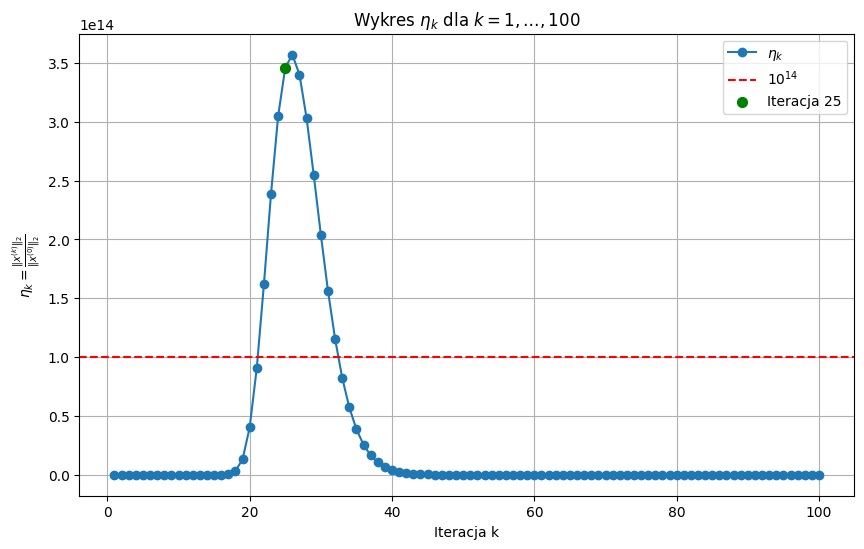

In [61]:
# Definicja macierzy B
n = 20
main_diag = np.linspace(0.025, 0.5, n)
upper_diag = np.full(n - 1, 5.0)
B = np.diag(main_diag) + np.diag(upper_diag, k=1)

# Inicjalizacja wektora x(0)
x_0 = np.ones(n)

# Obliczanie eta_k dla k = 1, ..., 100
iterations = 100
x_k = x_0.copy()
eta_k = []

for k in range(iterations):
    x_k = B @ x_k
    eta = np.linalg.norm(x_k, 2) / np.linalg.norm(x_0, 2)
    eta_k.append(eta)

# Wykres eta_k
plt.figure(figsize=(10, 6))
plt.plot(range(1, iterations + 1), eta_k, label=r'$\eta_k$', marker='o')
plt.axhline(y=10**14, color='r', linestyle='--', label=r'$10^{14}$')
plt.xlabel('Iteracja k')
plt.scatter(25, eta_k[24], color='g', s=50, zorder=5, label='Iteracja 25')
plt.ylabel(r'$\eta_k = \frac{\|x^{(k)}\|_2}{\|x^{(0)}\|_2}$')
plt.title(r'Wykres $\eta_k$ dla $k = 1, \ldots, 100$')
plt.legend()
plt.grid()


# Wyznaczenie najmniejszego k, dla którego ||x^(k)||_2 < ||x^(0)||_2
k_min = next((k + 1 for k, eta in enumerate(eta_k) if eta < 1), None) # sprawdzamy czemu wieksze od 1,bo jak podzielimy obustronnie to wystarczy przeleciec przez liste i znajdziemy
print(f"Najmniejsze k, dla którego ||x^(k)||_2 < ||x^(0)||_2: {k_min}")